In [1]:
import sys
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
from sympy import *
from scipy.linalg import expm
import math
import pickle
np.set_printoptions(threshold=sys.maxsize)

In [11]:
"""
Set Parameters: Number of Qubits N, external field h
"""

N = 10
h = 0.0

In [12]:
"""
X_i, Z_i are Pauli operators on site i 
e.g. X_i = I⨂..⨂I⨂X⨂I⨂... with the i-th tensor factor being X = 2x2 Pauli X operator
I is the identity operator
"""
X = [np.eye(1) for _ in range(N)]
Z = [np.eye(1) for _ in range(N)]

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

for n in range(N):
    for i in range(N):
        if i == n:
            X[n] = np.kron(X[n], sigma_x)
            Z[n] = np.kron(Z[n], sigma_z)
        else:
            X[n] = np.kron(X[n], np.eye(2))
            Z[n] = np.kron(Z[n], np.eye(2))

In [13]:
"""
Next we define the (Z_i Z_{i+1}+I)/2  operation
"""

ZZ = [0 for _ in range(N)]
for i in range(N - 1):
    ZZ[i] = ((np.eye(2**N) + np.matmul(Z[i],Z[i+1])) )/ 2.0

ZZ[N-1] = ((np.eye(2**N) + np.matmul(Z[N-1],Z[0])) )/ 2.0

In [14]:
"""
Finally, we need (X+I)/2 operator
"""
Xmod = [0 for _ in range(N)]
for i in range(N):
    Xmod[i] = (np.eye(2**N) + X[i]) / 2.0

In [15]:
"""
Construct Hamiltonian H
"""


H = np.zeros((2**N, 2**N))


for i in range(N):
    H += -ZZ[i] - h * Xmod[i]

evals, _ = LA.eig(H)

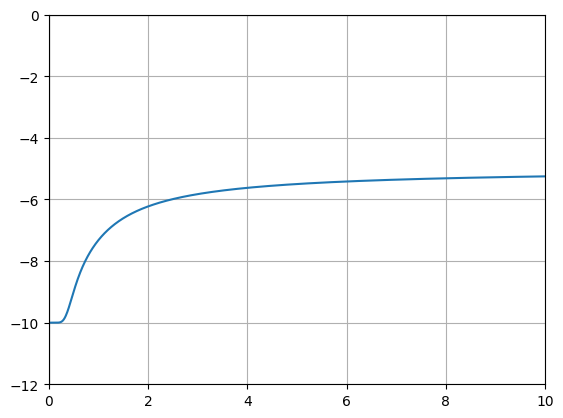

In [16]:
"""
Expansion order L = infinity
"""
beta = symbols('beta')
Z = sum([exp(-E * beta) for E in evals])
En_fct = diff(-log(Z),beta)
x_max = 10
y_min = -12
E_avg = [En_fct.subs(beta,1.0/Tvals) for Tvals in np.linspace(0.01,x_max,1000)]
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.xlim((0,x_max))
plt.ylim((y_min,0))
plt.plot(np.linspace(0.01,x_max,1000),E_avg)
plt.savefig("Mean_Energy_INF_vs_T.pdf")

In [ ]:
"""
Expansion to finite order beta**L
"""
# L_list = [10,20,30,40]
L_list = [10]
plot_data = []
for L in L_list:
    f = sum(sum([1.0/math.factorial(n) * (-E * beta)**n for E in evals]) for n in range(L+1))
    En_fct = diff(-log(f),beta)
    E_avg = [En_fct.subs(beta,1.0/Tvals) for Tvals in np.linspace(0.01,10,1000)]
    plot_data.append([L,[np.linspace(0.01,x_max,1000),E_avg]])
    plt.plot(np.linspace(0.01,x_max,1000),E_avg)
    print("L = ",L," done")
plt.savefig("Mean_Energy_vs_T.pdf")